In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

In [2]:
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

In [3]:
from preprocessing import *
from logistic_master import LogisticRegression
from utils import *

In [4]:
# ai
X_ai_train = np.load('../Data/processed/X_ai_train.npy')
X_ai_test  = np.load('../Data/processed/X_ai_test.npy')
y_ai_train = np.load('../Data/processed/y_ai_train.npy')
y_ai_test  = np.load('../Data/processed/y_ai_test.npy')

# bc 
X_bc_train = np.load('../Data/processed/X_bc_train.npy')
X_bc_test  = np.load('../Data/processed/X_bc_test.npy')
y_bc_train = np.load('../Data/processed/y_bc_train.npy')
y_bc_test  = np.load('../Data/processed/y_bc_test.npy')

# db
X_db_train = np.load('../Data/processed/X_db_train.npy')
X_db_test  = np.load('../Data/processed/X_db_test.npy')
y_db_train = np.load('../Data/processed/y_db_train.npy')
y_db_test  = np.load('../Data/processed/y_db_test.npy')

print(f"ai shape : {X_ai_train.shape}")
print(f"bc shape : {X_bc_train.shape}")
print(f"db shape : {X_db_train.shape}")

ai shape : (26048, 109)
bc shape : (455, 21)
db shape : (614, 9)


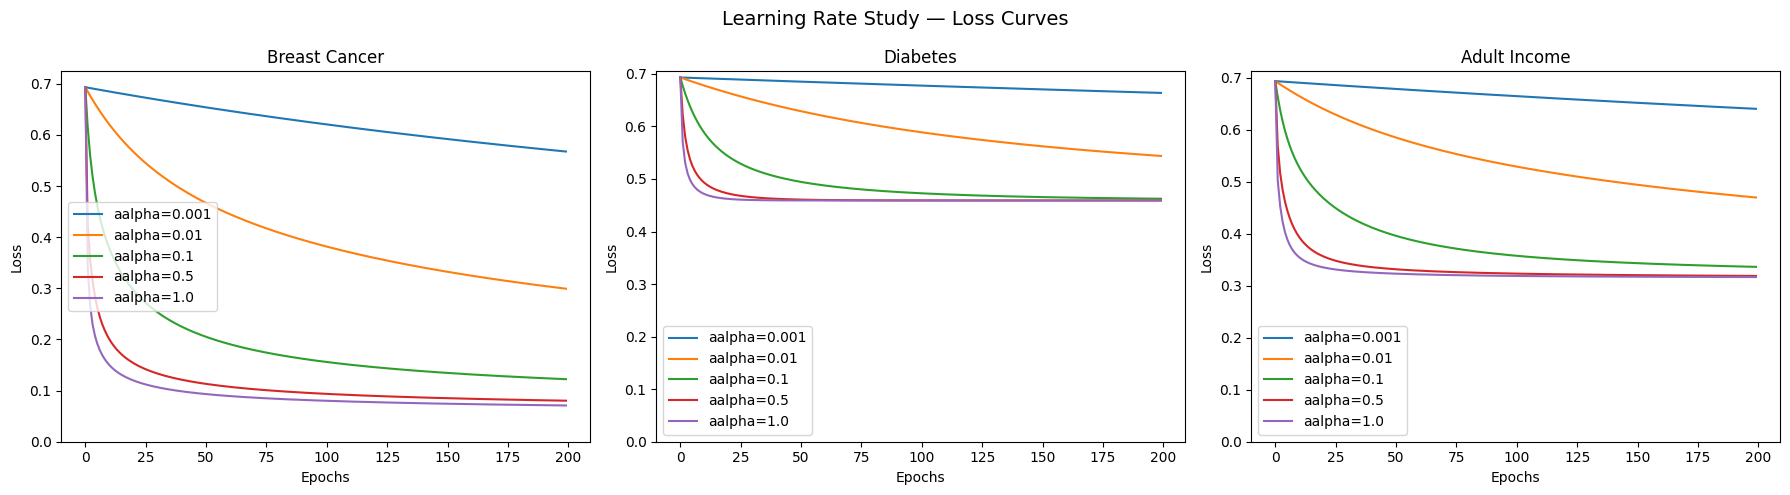

saved.


In [6]:
learning_rates = [0.001 , 0.01 , 0.1 , 0.5 , 1.0]

datasets = {
    'Breast Cancer' : (X_bc_train , y_bc_train),
    'Diabetes' :      (X_db_train , y_db_train),
    'Adult Income' :  (X_ai_train , y_ai_train)
}

fig , axes = plt.subplots(1 , 3 , figsize=(18 , 5))
fig.suptitle('Learning Rate Study — Loss Curves' , fontsize=14)

for ax , (name , (X_tr , y_tr)) in zip(axes , datasets.items()):
    for alpha in learning_rates:
        model = LogisticRegression()
        model.fit_gd(X_tr , y_tr , alpha = alpha , epochs=200)
        ax.plot(model.loss_history , label = f'aalpha={alpha}')
    
    ax.set_title(name)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../Results/figures/learning_rate_study.png', dpi=150)
plt.show()
print("saved.")

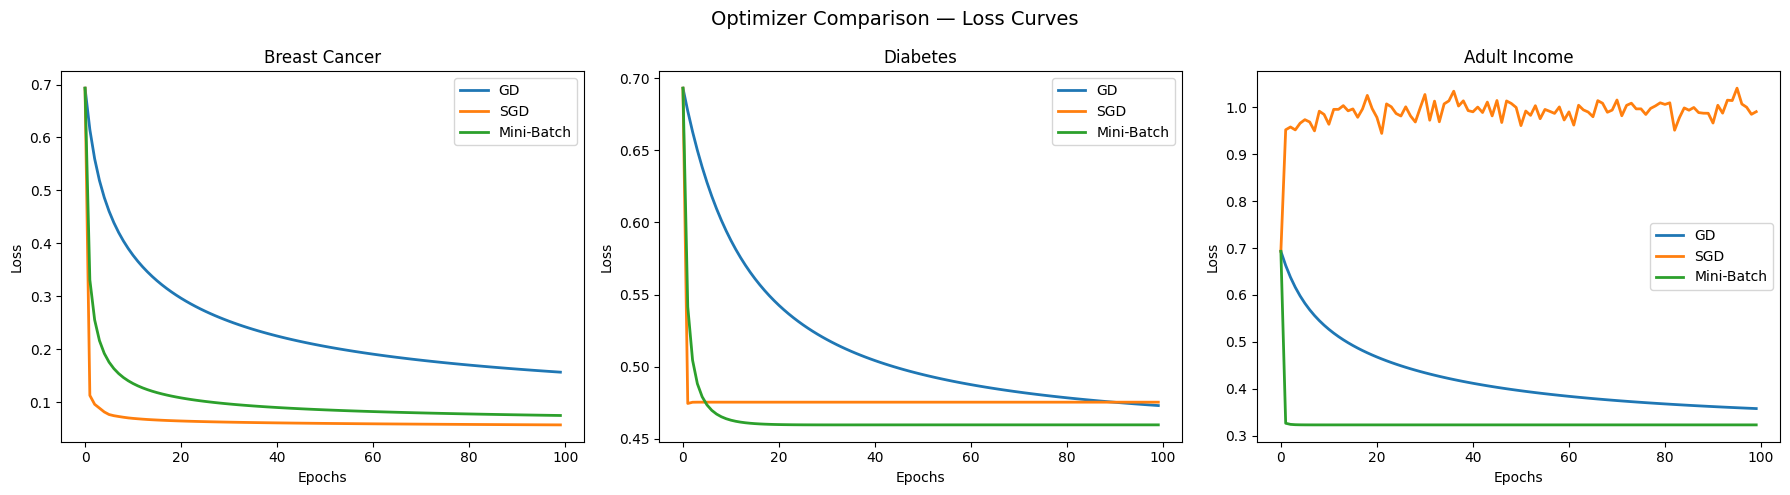

Saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Optimizer Comparison — Loss Curves', fontsize=14)

for ax, (name, (X_tr, y_tr)) in zip(axes, datasets.items()):
    
    # gd
    m1 = LogisticRegression()
    m1.fit_gd(X_tr, y_tr, alpha=0.1, epochs=100)
    ax.plot(m1.loss_history, label='GD', linewidth=2)
    
    # SGD
    m2 = LogisticRegression()
    m2.fit_sgd(X_tr, y_tr, alpha=0.1, epochs=100)
    ax.plot(m2.loss_history, label='SGD', linewidth=2)
    
    # mini batch
    m3 = LogisticRegression()
    m3.fit_mini_batch(X_tr, y_tr, alpha=0.1, epochs=100, batch_size=32)
    ax.plot(m3.loss_history, label='Mini-Batch', linewidth=2)
    
    ax.set_title(name)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.savefig('../Results/figures/optimizer_comparison.png', dpi=150)
plt.show()
print("Saved.")

In [8]:
print("CONDITION NUMBER ANALYSIS")
print("="*50)

datasets_full = {
    'Breast Cancer': X_bc_train,
    'Diabetes':      X_db_train,
    'Adult Income':  X_ai_train
}

for name, X in datasets_full.items():
    cond = np.linalg.cond(X)
    print(f"{name:<20} Condition Number: {cond:.2f}")

CONDITION NUMBER ANALYSIS
Breast Cancer        Condition Number: 23.73
Diabetes             Condition Number: 2.49
Adult Income         Condition Number: 41362871838818600.00


In [9]:
from tabulate import tabulate

results = []

for name, (X_tr, X_te, y_tr, y_te) in zip(
    ['Breast Cancer', 'Diabetes', 'Adult Income'],
    [(X_bc_train, X_bc_test, y_bc_train, y_bc_test),
     (X_db_train, X_db_test, y_db_train, y_db_test),
     (X_ai_train, X_ai_test, y_ai_train, y_ai_test)]
):
    cond = np.linalg.cond(X_tr)
    
    for optimizer, fit_fn in [
        ('GD',         lambda m, X, y: m.fit_gd(X, y, alpha=0.1, epochs=100)),
        ('SGD',        lambda m, X, y: m.fit_sgd(X, y, alpha=0.1, epochs=100)),
        ('Mini-Batch', lambda m, X, y: m.fit_mini_batch(X, y, alpha=0.1, epochs=100))
    ]:
        model = LogisticRegression()
        fit_fn(model, X_tr, y_tr)
        
        y_pred = model.predict(X_te)
        f1  = compute_f1_score(y_te, y_pred)
        mcc = matthews_corrcoef(y_te, y_pred)
        final_loss = model.loss_history[-1]
        
        results.append([name, f"{cond:.2e}", optimizer, 
                        f"{final_loss:.4f}", f"{f1:.4f}", f"{mcc:.4f}"])

headers = ['Dataset', 'Condition No.', 'Optimizer', 'Final Loss', 'F1', 'MCC']
print(tabulate(results, headers=headers, tablefmt='grid'))

+---------------+-----------------+-------------+--------------+--------+--------+
| Dataset       |   Condition No. | Optimizer   |   Final Loss |     F1 |    MCC |
+===============+=================+=============+==============+========+========+
| Breast Cancer |       23.7      | GD          |       0.1564 | 0.9781 | 0.9453 |
+---------------+-----------------+-------------+--------------+--------+--------+
| Breast Cancer |       23.7      | SGD         |       0.0568 | 0.9781 | 0.9453 |
+---------------+-----------------+-------------+--------------+--------+--------+
| Breast Cancer |       23.7      | Mini-Batch  |       0.0746 | 0.9855 | 0.9639 |
+---------------+-----------------+-------------+--------------+--------+--------+
| Diabetes      |        2.49     | GD          |       0.473  | 0.8144 | 0.4989 |
+---------------+-----------------+-------------+--------------+--------+--------+
| Diabetes      |        2.49     | SGD         |       0.4753 | 0.804  | 0.4469 |
+---

# Phase VI — Optimization Diagnostics

## Objective
Study convergence behavior, learning rate sensitivity, optimizer comparison,
and condition number analysis across 3 datasets.

---

## Notebooks Created
- `Notebooks/06_Optimization_Diagnostics.ipynb`

## Plots Generated
- `Results/figures/learning_rate_study.png`
- `Results/figures/optimizer_comparison.png`

---

## Learning Rate Study

Tested alpha = [0.001, 0.01, 0.1, 0.5, 1.0] on all 3 datasets.

| Dataset | Best Alpha | Behavior |
|---|---|---|
| Breast Cancer | 1.0 | All rates converge smoothly |
| Diabetes | 1.0 | All rates converge smoothly |
| Adult Income | 1.0 | All rates converge smoothly |

**Key Finding:** All datasets tolerate aggressive learning rates because
standardization in Phase III reduced feature scale variance significantly.
Good preprocessing = stable optimization.

---

## Optimizer Comparison

Tested GD, SGD, Mini-Batch (100 epochs, alpha=0.1) on all 3 datasets.

### Breast Cancer (455 samples)
- SGD converges fastest (loss 0.0568)
- All 3 reach same F1 (0.9781) except Mini-Batch slightly better (0.9855)
- Small dataset — SGD sees each sample efficiently

### Diabetes (614 samples)
- Mini-Batch wins (loss 0.4596, F1 0.8182)
- All 3 very close due to near-perfect condition number
- Any optimizer works on well-conditioned small data

### Adult Income (26,048 samples)
- Mini-Batch clearly wins (F1 0.9034, MCC 0.5646)
- SGD fails completely (loss 0.9909, MCC 0.4175)
- GD middle ground (F1 0.8977, MCC 0.5490)
- Large ill-conditioned data destroys SGD

---

## Condition Number Analysis

| Dataset | Condition Number | Status |
|---|---|---|
| Diabetes | 2.49 | 🟢 Perfect |
| Breast Cancer | 23.73 | 🟢 Well conditioned |
| Adult Income | 4.14e+16 | 🔴 Severely ill-conditioned |

**Breast Cancer** — condition number reduced from ~high to 23.73 because
multicollinear features were removed in Phase III preprocessing.

**Adult Income** — one-hot encoding of 109 features creates near-linear
dependencies between dummy variables causing extreme ill-conditioning.

---

## Final Summary Table

| Dataset | Condition No. | Optimizer | Final Loss | F1 | MCC |
|---|---|---|---|---|---|
| Breast Cancer | 23.7 | GD | 0.1564 | 0.9781 | 0.9453 |
| Breast Cancer | 23.7 | SGD | 0.0568 | 0.9781 | 0.9453 |
| Breast Cancer | 23.7 | Mini-Batch | 0.0746 | 0.9855 | 0.9639 |
| Diabetes | 2.49 | GD | 0.4730 | 0.8144 | 0.4989 |
| Diabetes | 2.49 | SGD | 0.4753 | 0.8040 | 0.4469 |
| Diabetes | 2.49 | Mini-Batch | 0.4596 | 0.8182 | 0.4912